# **Assignment: Neural Networks**

**Course:** AI 500
**Assignment:** PA5
**Total Marks:** [100]

### **Plagiarism Policy**

  * All work must be done independently.
  * Plagiarism will result in a grade of zero.
  * Plagiarism is <span style="color:red">strictly prohibited — submit your own original work.</span>

### **General Instructions**

  * **Do not** remove pre-written code.
  * Attempt all the questions.
  * Ensure all cells are run before submission.
  * Your analysis in the final section is crucial for full credit.
  * Fill the top markdown cell with your **Full Name** and **Roll Number**.  
  * Save your notebook exactly as `PA5_<your_roll_number>.ipynb` (example: `PA5_26100053.ipynb`).  
  * Due date: **8 December 2025** (submit by 23:55).  
  
### **Student Details**

Write your name and roll number here:
- `Name: ` Muhammad Ahamd
- `Roll number:`25280065


-----

# **Part A - MLPs vs CNNs** 

## **1) Import Libraries and Setup**

All relevant libraries are imported below. Set your device to GPU/MPS if available. (Do not make any other imports)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import random

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

Using Device: cpu


## **2) Load and Preprocess CIFAR-10**

**Task 2.1: Define Transforms**

  * CIFAR-10 images are 3-channel (RGB).
  * Define a transform to **Convert to Tensor** and **Normalize** the images.
  * *Hint: Standard CIFAR-10 normalization means are (0.5, 0.5, 0.5) and stds are (0.5, 0.5, 0.5) for this assignment.*

**Task 2.2: Load Dataset and Create Splits**

  * Download CIFAR-10 using `torchvision`.
  * Split the **training** data (50,000 samples) into **Train (45,000)** and **Validation (5,000)**.
  * Keep the **Test** set (10,000 samples) separate.
  * Create DataLoaders for all three sets (Batch size: 64).

In [43]:
# TODO: Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# TODO: Load Dataset

train_full = datasets.CIFAR10(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_set = datasets.CIFAR10(
    root="./data",
    train=False,
    transform=transform,
    download=True
)
# TODO: Create Split
train_size = 45000
val_size = 5000
train_set, val_set = random_split(train_full, [train_size, val_size])

# TODO: Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Print split sizes
print("Train samples:", len(train_set))
print("Validation samples:", len(val_set))
print("Test samples:", len(test_set))

Train samples: 45000
Validation samples: 5000
Test samples: 10000


## **3) Visualization**

**Task:** Write a function `visualize_samples` to display random images from the batch with their ground truth labels.

  * *Note: Since you normalized the data, the images might look dark or distorted. You need to un-normalize them for proper visualization.*



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8509804..0.77254903].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85882354..0.9764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81960785..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.96862745..1.0].


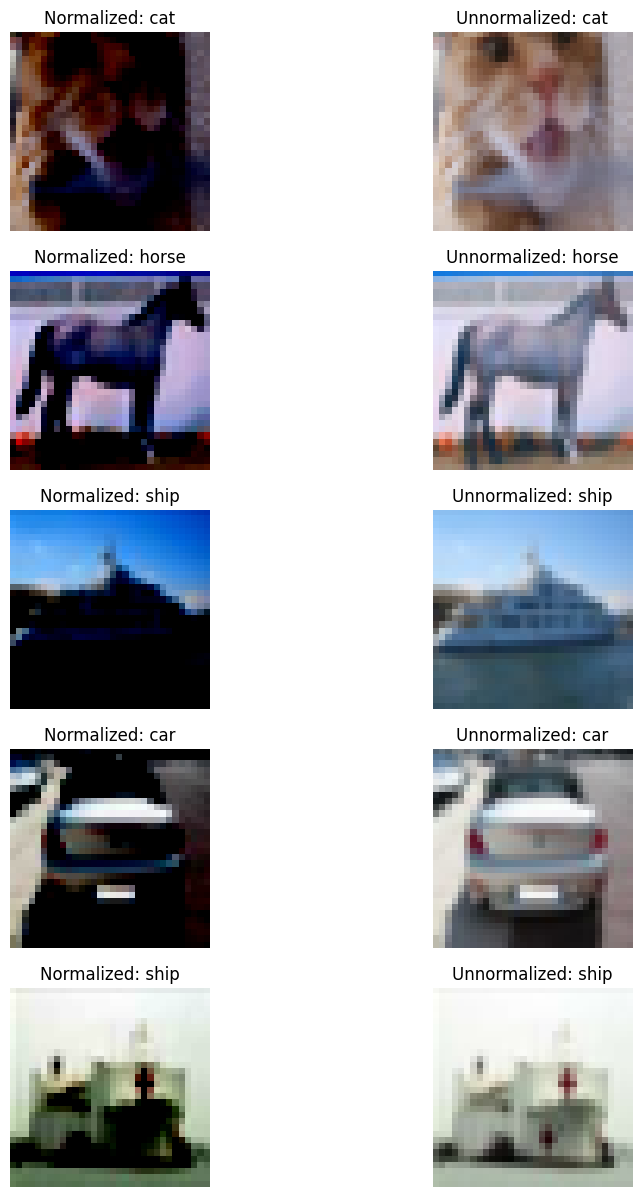

In [44]:
def unnormalize_image(image, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)):
    return image * np.array(std)[:, None, None] + np.array(mean)[:, None, None]

def visualize_samples(dataloader, classes, num_samples=5):
    images, labels = next(iter(dataloader))
    images_normalized = images.numpy().transpose((0, 2, 3, 1))
    images_unnormalized = unnormalize_image(images.numpy(), mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)).transpose((0, 2, 3, 1))
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(10, num_samples*3))
    for i in range(num_samples):
        axes[i, 0].imshow(images_normalized[i])
        axes[i, 0].set_title(f"Normalized: {classes[labels[i]]}")
        axes[i, 0].axis('off') 
        
        axes[i, 1].imshow(images_unnormalized[i])
        axes[i, 1].set_title(f"Unnormalized: {classes[labels[i]]}")
        axes[i, 1].axis('off')
    plt.show()

# Run visualization
visualize_samples(train_loader, classes, 5)

## **4) Model 1: Fully Connected Neural Network (FCNN)**

**Task 4.1: Architecture**
Create a class `FCNN` with the following constraints:

  * **Input:** 32x32x3 RGB image.
  * **Hidden Layers:** Use at least 3 hidden layers with **ReLU** activation.
  * **Parameters:** The total parameter count should be **greater than 500,000**.
  * **Output:** 10 classes.

**Task 4.2: Parameter Count**
Implement a function to count and print the number of trainable parameters.

In [2]:
class FCNN(nn.Module):
    def __init__(self):
        super(FCNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 32 * 3, 155)
        self.fc2 = nn.Linear(155, 125)
        self.fc3 = nn.Linear(125, 32)
        self.fc4 = nn.Linear(32, 10)
        self.relu = nn.ReLU()
        

        # TODO: Define Linear layers to reach > 500,000 parameters
        pass

    def forward(self, x):
        # TODO: Flatten input and pass through layers
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

def count_parameters(model):
    # TODO: Return total trainable parameters
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Initialize model
fcnn_model = FCNN().to(DEVICE)
print(f"FCNN Parameters: {count_parameters(fcnn_model)}")

FCNN Parameters: 500177



## **5) Training and Evaluation Helper Functions**

To avoid code repetition, define generic functions that can be used for any model.

**Task 5.1: Train Function**

  * Input: model, dataloader, criterion, optimizer.
  * Action: Perform forward pass, loss calculation, backward pass, and optimization.
  * Return: Average loss and Accuracy for the epoch.

**Task 5.2: Evaluate Function**

  * Input: model, dataloader, criterion.
  * Action: Perform forward pass (no grad), calculate loss and accuracy.
  * Return: Average loss and Accuracy.



In [3]:

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    loss_sum = correct = total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        correct += out.argmax(1).eq(y).sum().item()
        total += y.size(0)
    return loss_sum / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    loss_sum = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct += out.argmax(1).eq(y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total
    


## **6) Train FCNN**

**Task:**

1.  Define Optimizer, Learning Rate, and Criterion.
2.  Run the training loop for **10-15 epochs**.
3.  Store Train Loss, Val Loss, Train Acc, and Val Acc for plotting.
4.  Plot the Loss and Accuracy curves.


In [47]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fcnn_model.parameters(), lr=0.001)

epochs =15
train_losses, val_losses = [], []
train_accs = []
val_accs = []


In [48]:
# TODO: Training Loop
for epoch in range(epochs):
    tr_loss, tr_acc = train_one_epoch(fcnn_model, train_loader, criterion, optimizer)
    v_loss, v_acc = evaluate(fcnn_model, val_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(v_loss)
    train_accs.append(tr_acc)
    val_accs.append(v_acc)

    print(f"Epoch {epoch+1}/{epochs}  "
          f"Train Loss: {tr_loss:.4f}  Val Loss: {v_loss:.4f}  "
          f"Train Acc: {tr_acc:.4f}  Val Acc: {v_acc:.4f}")


Epoch 1/15  Train Loss: 1.6843  Val Loss: 1.5409  Train Acc: 0.4004  Val Acc: 0.4522
Epoch 2/15  Train Loss: 1.4652  Val Loss: 1.4492  Train Acc: 0.4819  Val Acc: 0.4894
Epoch 3/15  Train Loss: 1.3614  Val Loss: 1.4186  Train Acc: 0.5197  Val Acc: 0.4958
Epoch 4/15  Train Loss: 1.2760  Val Loss: 1.4149  Train Acc: 0.5525  Val Acc: 0.5094
Epoch 5/15  Train Loss: 1.2097  Val Loss: 1.3987  Train Acc: 0.5715  Val Acc: 0.5184
Epoch 6/15  Train Loss: 1.1457  Val Loss: 1.3861  Train Acc: 0.5964  Val Acc: 0.5306
Epoch 7/15  Train Loss: 1.0906  Val Loss: 1.3728  Train Acc: 0.6146  Val Acc: 0.5336
Epoch 8/15  Train Loss: 1.0378  Val Loss: 1.3825  Train Acc: 0.6316  Val Acc: 0.5270
Epoch 9/15  Train Loss: 0.9890  Val Loss: 1.4081  Train Acc: 0.6506  Val Acc: 0.5216
Epoch 10/15  Train Loss: 0.9448  Val Loss: 1.4260  Train Acc: 0.6650  Val Acc: 0.5294
Epoch 11/15  Train Loss: 0.8963  Val Loss: 1.4979  Train Acc: 0.6800  Val Acc: 0.5188
Epoch 12/15  Train Loss: 0.8624  Val Loss: 1.4926  Train Acc: 0

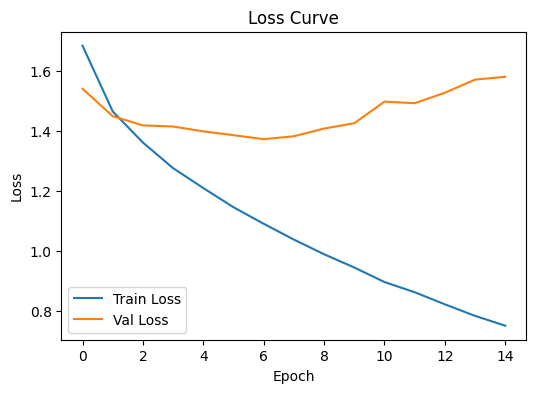

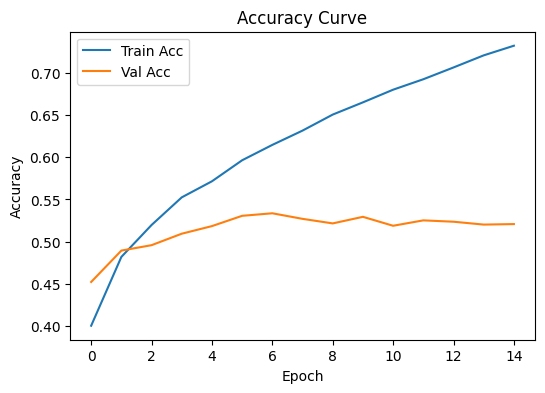

In [59]:
# TODO: Plot Training vs Validation Loss and Accuracy
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


## **7) FCNN Analysis**

**Task 7.1: Test Set Evaluation**
Evaluate the FCNN on the `test_loader` and print the classification report.

**Task 7.2: Confusion Matrix**
Generate and plot a confusion matrix using Seaborn.

**Task 7.3: Sample Visualization**
Visualize 3 **Correctly** classified samples and 3 **Incorrectly** classified samples with their Predicted vs. Actual labels.


In [ ]:
# TODO: Evaluate on Test Set

# Classification Report
test_loss, test_acc = evaluate(fcnn_model, test_loader, criterion)
print("Test Loss:", test_loss, "Test Acc:", test_acc)

all_preds, all_labels = [], []
fcnn_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        p = fcnn_model(x).argmax(1)
        all_preds.extend(p.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=classes))

Test Loss: 1.6387758302688598 Test Acc: 0.5156
              precision    recall  f1-score   support

       plane       0.55      0.52      0.53      1000
         car       0.67      0.56      0.61      1000
        bird       0.44      0.41      0.43      1000
         cat       0.36      0.30      0.33      1000
        deer       0.46      0.43      0.44      1000
         dog       0.40      0.52      0.45      1000
        frog       0.55      0.57      0.56      1000
       horse       0.57      0.59      0.58      1000
        ship       0.65      0.64      0.64      1000
       truck       0.54      0.62      0.58      1000

    accuracy                           0.52     10000
   macro avg       0.52      0.52      0.51     10000
weighted avg       0.52      0.52      0.51     10000



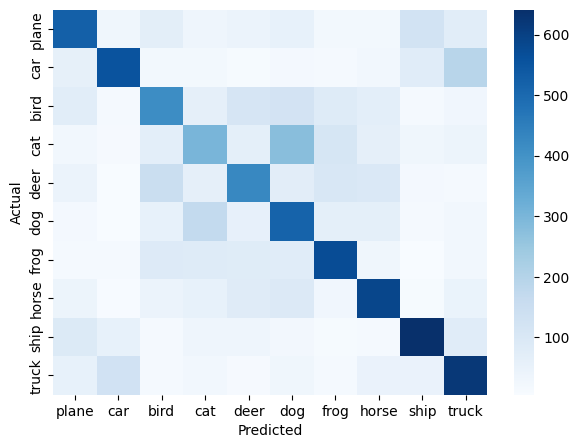

In [51]:
# TODO: Generate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()


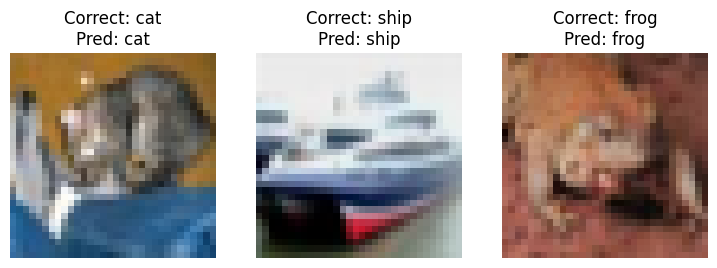

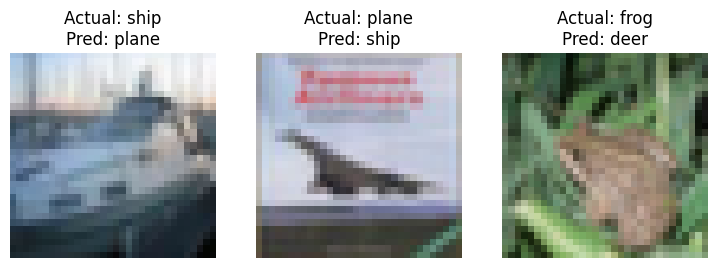

In [52]:
# TODO: Visualize Correct/Incorrect Samples
correct, wrong = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        p = fcnn_model(x).argmax(1)
        for i in range(len(p)):
            if p[i] == y[i] and len(correct) < 3:
                correct.append((x[i].cpu(), y[i].cpu(), p[i].cpu()))
            if p[i] != y[i] and len(wrong) < 3:
                wrong.append((x[i].cpu(), y[i].cpu(), p[i].cpu()))
        if len(correct) == 3 and len(wrong) == 3:
            break
def un(img): return img.numpy().transpose(1,2,0) * 0.5 + 0.5
plt.figure(figsize=(9,3))
for i,(img,y,p) in zip(range(3), correct):
    plt.subplot(1,3,i+1)
    plt.imshow(un(img))
    plt.title(f"Correct: {classes[y]}\nPred: {classes[p]}")
    plt.axis("off")
plt.show()

plt.figure(figsize=(9,3))
for i,(img,y,p) in zip(range(3), wrong):
    plt.subplot(1,3,i+1)
    plt.imshow(un(img))
    plt.title(f"Actual: {classes[y]}\nPred: {classes[p]}")
    plt.axis("off")
plt.show()





## **8) Model 2: Convolutional Neural Network (CNN)**

**Task 8.1: Architecture**
Create a class `CNN` with the following constraints:

  * **Input:** 32x32x3 Image.
  * **Layers:** Use `Conv2d`, `MaxPool2d`, `ReLU`, and `Linear` layers.
  * **Parameters:** The total parameter count should be **less than 250,000**.



In [63]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc = nn.Linear(128*4*4, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Initialize model
cnn_model = SimpleCNN().to(DEVICE)
print(f"CNN Parameters: {count_parameters(cnn_model)}")


CNN Parameters: 113738




## **9) Train CNN**

**Task:**

1.  Define Optimizer and Criterion.
2.  Train the CNN using the **same** `train_one_epoch` and `evaluate` functions defined earlier.
3.  Train for the same number of epochs as FCNN.
4.  Plot Loss and Accuracy curves.
 


In [65]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

epochs = 15
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [66]:
# TODO: Training Loop for CNN (Same as FCNN)
for epoch in range(epochs):
    tr_loss, tr_acc = train_one_epoch(cnn_model, train_loader, criterion, optimizer)
    v_loss, v_acc = evaluate(cnn_model, val_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(v_loss)
    train_accs.append(tr_acc)
    val_accs.append(v_acc)

    print(f"Epoch {epoch+1}/{epochs}  "
          f"Train Loss: {tr_loss:.4f}  Val Loss: {v_loss:.4f}  "
          f"Train Acc: {tr_acc:.4f}  Val Acc: {v_acc:.4f}")

Epoch 1/15  Train Loss: 1.3920  Val Loss: 1.1434  Train Acc: 0.4997  Val Acc: 0.5976
Epoch 2/15  Train Loss: 0.9937  Val Loss: 0.9220  Train Acc: 0.6524  Val Acc: 0.6778
Epoch 3/15  Train Loss: 0.8333  Val Loss: 0.8444  Train Acc: 0.7094  Val Acc: 0.7046
Epoch 4/15  Train Loss: 0.7205  Val Loss: 0.7924  Train Acc: 0.7520  Val Acc: 0.7262
Epoch 5/15  Train Loss: 0.6402  Val Loss: 0.7884  Train Acc: 0.7799  Val Acc: 0.7264
Epoch 6/15  Train Loss: 0.5717  Val Loss: 0.7565  Train Acc: 0.8035  Val Acc: 0.7446
Epoch 7/15  Train Loss: 0.5036  Val Loss: 0.7733  Train Acc: 0.8270  Val Acc: 0.7390
Epoch 8/15  Train Loss: 0.4458  Val Loss: 0.8470  Train Acc: 0.8464  Val Acc: 0.7274
Epoch 9/15  Train Loss: 0.3938  Val Loss: 0.8447  Train Acc: 0.8631  Val Acc: 0.7350
Epoch 10/15  Train Loss: 0.3407  Val Loss: 0.8657  Train Acc: 0.8814  Val Acc: 0.7374
Epoch 11/15  Train Loss: 0.2948  Val Loss: 0.9152  Train Acc: 0.8999  Val Acc: 0.7392
Epoch 12/15  Train Loss: 0.2568  Val Loss: 0.9947  Train Acc: 0

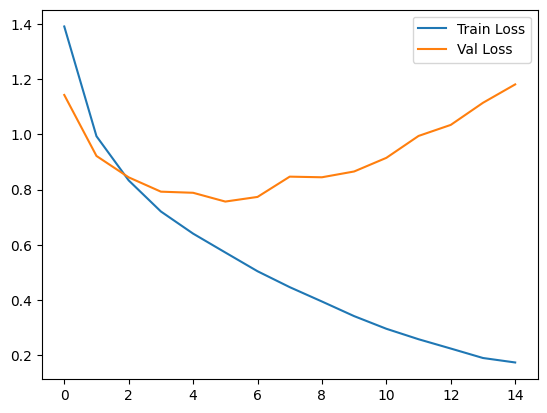

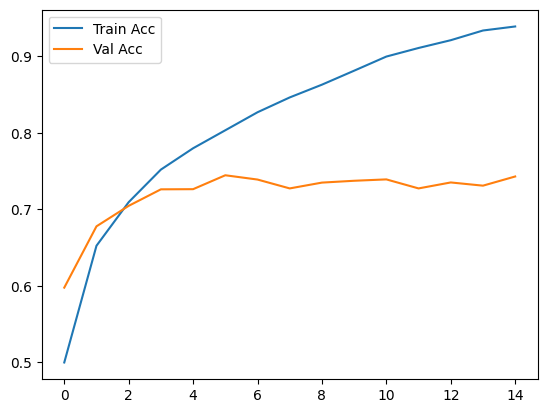

In [67]:
# TODO: Plot Curves
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.show()

plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.show()



## **10) CNN Analysis**

**Task 10.1: Test Set Evaluation**
Evaluate the CNN on the `test_loader`.

**Task 10.2: Confusion Matrix**
Generate and plot the confusion matrix for the CNN.

**Task 10.3: Sample Visualization**
Visualize 3 Correct and 3 Incorrect samples for the CNN.


In [68]:
# TODO: Evaluate CNN on Test Set
test_loss, test_acc = evaluate(cnn_model, test_loader, criterion)
print("Test Loss:", test_loss, "Test Acc:", test_acc)

all_preds, all_labels = [], []
cnn_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        p = cnn_model(x).argmax(1)
        all_preds.extend(p.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=classes))


Test Loss: 1.230716152191162 Test Acc: 0.7309
              precision    recall  f1-score   support

       plane       0.75      0.77      0.76      1000
         car       0.85      0.86      0.86      1000
        bird       0.72      0.55      0.62      1000
         cat       0.51      0.57      0.54      1000
        deer       0.69      0.71      0.70      1000
         dog       0.60      0.65      0.62      1000
        frog       0.81      0.81      0.81      1000
       horse       0.83      0.71      0.77      1000
        ship       0.82      0.85      0.84      1000
       truck       0.78      0.83      0.80      1000

    accuracy                           0.73     10000
   macro avg       0.74      0.73      0.73     10000
weighted avg       0.74      0.73      0.73     10000



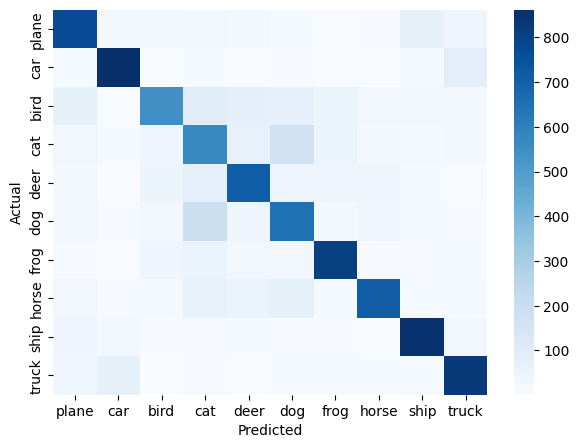

In [69]:
# TODO: Confusion Matrix for CNN
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


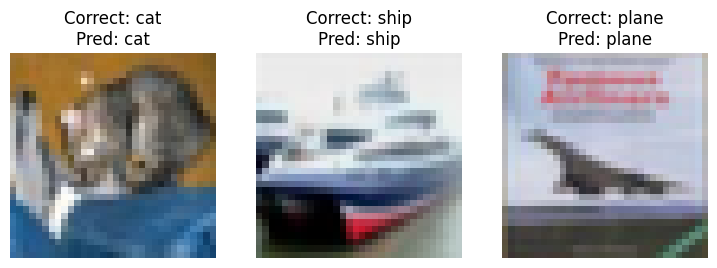

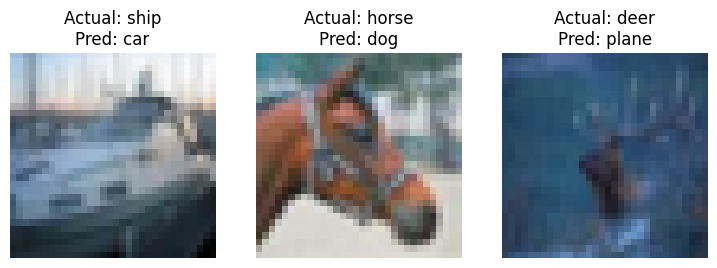

In [70]:
# TODO: Visualizations
correct, wrong = [], []

cnn_model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        p = cnn_model(x).argmax(1)

        for i in range(len(p)):
            if p[i] == y[i] and len(correct) < 3:
                correct.append((x[i].cpu(), y[i].cpu(), p[i].cpu()))
            if p[i] != y[i] and len(wrong) < 3:
                wrong.append((x[i].cpu(), y[i].cpu(), p[i].cpu()))
        if len(correct) == 3 and len(wrong) == 3:
            break
def un(img): return img.numpy().transpose(1,2,0) * 0.5 + 0.5
plt.figure(figsize=(9,3))
for i,(img,y,p) in zip(range(3), correct):
    plt.subplot(1,3,i+1)
    plt.imshow(un(img))
    plt.title(f"Correct: {classes[y]}\nPred: {classes[p]}")
    plt.axis("off")
plt.show()
plt.figure(figsize=(9,3))
for i,(img,y,p) in zip(range(3), wrong):
    plt.subplot(1,3,i+1)
    plt.imshow(un(img))
    plt.title(f"Actual: {classes[y]}\nPred: {classes[p]}")
    plt.axis("off")
plt.show()



## **11) Final Analysis & Conclusion**

**Question:**
Compare the performance of the FCNN (approx. 500K parameters) vs. the CNN (approx. 250K parameters).

1.  Which model performed better on the Test set?
2.  Why did the CNN perform better (or worse) despite having significantly fewer parameters?

**Answer:** 

1. 
The CNN performed better on the test set than the FCNN, even though the CNN had fewer parameters


2. 
Because CNNs are built for images.
They look at small local patterns (edges, shapes, textures) using filters.
This helps them understand pictures in a smarter way.

The FCNN treats the image like a long list of numbers.
It does not see shapes or nearby pixels, so it learns less useful features.

So even with fewer parameters, the CNN learns better image features, which makes it perform better.

# **Part B - Transfer Learning** 

In this part, you will train two models on the **Chest X-ray Pneumonia dataset** (Normal vs Pneumonia):
1. A small CNN trained from scratch
2. A pretrained ResNet-18 fine-tuned on the same dataset

### **Dataset Instructions**

**⚠️ IMPORTANT: You must manually download the dataset before starting this section.**

1. Download the dataset from Kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
2. Extract the downloaded archive
3. Place the extracted folder in your working directory (same location as this notebook)
4. The folder structure should look like:
   ```
   chest_xray/
   ├── train/
   │   ├── NORMAL/
   │   └── PNEUMONIA/
   ├── val/
   │   ├── NORMAL/
   │   └── PNEUMONIA/
   └── test/
       ├── NORMAL/
       └── PNEUMONIA/
   ```

### **Your Goals:**
- Build & train a simple CNN from scratch
- Load & fine-tune a pretrained ResNet-18
- Compare both models based on accuracy, loss curves, training speed, and generalization
- Write a final analysis comparing both approaches

## **1) Data Loading**

**Task: Load the Chest X-ray dataset and prepare DataLoaders for train, validation, and test sets.**


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = datasets.ImageFolder("chest_xray/train", transform=transform)
val_data   = datasets.ImageFolder("chest_xray/val", transform=transform)
test_data  = datasets.ImageFolder("chest_xray/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

classes = train_data.classes
print("Classes:", classes)
print("Train:", len(train_data), "Val:", len(val_data), "Test:", len(test_data))

Classes: ['NORMAL', 'PNEUMONIA']
Train: 5216 Val: 16 Test: 624


## **2) Model A — CNN From Scratch**

**Task: Define your own small CNN architecture for training from scratch.**

In [5]:
def build_cnn_model():
    model = nn.Sequential(
        nn.Conv2d(3, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        nn.Conv2d(16, 32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        nn.Conv2d(32, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2, 2),

        nn.Flatten(),
        nn.Linear(64 * 28 * 28, 2)
    )
    return model.to(DEVICE)


## **3) Train Scratch Model**
**Task: Train your CNN from scratch and record training/validation accuracy for multiple epochs.**

In [6]:
model_a = build_cnn_model()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_a.parameters(), lr=0.001)

epochs = 5
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_a, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model_a, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}")


Epoch 1/5  Train Loss: 0.2223  Val Loss: 0.9324  Train Acc: 0.9036  Val Acc: 0.6250
Epoch 2/5  Train Loss: 0.1003  Val Loss: 0.1277  Train Acc: 0.9622  Val Acc: 0.9375
Epoch 3/5  Train Loss: 0.0697  Val Loss: 0.8004  Train Acc: 0.9760  Val Acc: 0.6875
Epoch 4/5  Train Loss: 0.0586  Val Loss: 0.2671  Train Acc: 0.9791  Val Acc: 0.8750
Epoch 5/5  Train Loss: 0.0400  Val Loss: 0.1949  Train Acc: 0.9860  Val Acc: 0.8750


## **4) Model B — Transfer Learning with ResNet-18**
**Task: Load a pretrained ResNet-18, freeze its layers, and replace the final classifier.**

In [7]:
from torchvision.models import resnet18
def build_resnet_model():
    model = resnet18(weights="IMAGENET1K_V1")

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, 2)

    return model.to(DEVICE)

## **5) Train ResNet Model**
**Task: Train the ResNet model and record training/validation accuracy.**

In [8]:
model_b = build_resnet_model()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_b.fc.parameters(), lr=0.0005)

epochs = 5
resnet_train_losses, resnet_val_losses = [], []
resnet_train_accs, resnet_val_accs = [], []

In [9]:
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_b, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model_b, val_loader, criterion)

    resnet_train_losses.append(train_loss)
    resnet_val_losses.append(val_loss)
    resnet_train_accs.append(train_acc)
    resnet_val_accs.append(val_acc) 

    print(f"Epoch {epoch+1}/{epochs}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}")


Epoch 1/5  Train Loss: 0.3083  Val Loss: 0.5420  Train Acc: 0.8677  Val Acc: 0.6250
Epoch 2/5  Train Loss: 0.1933  Val Loss: 0.5289  Train Acc: 0.9239  Val Acc: 0.6250
Epoch 3/5  Train Loss: 0.1688  Val Loss: 0.4865  Train Acc: 0.9350  Val Acc: 0.6875
Epoch 4/5  Train Loss: 0.1555  Val Loss: 0.4120  Train Acc: 0.9388  Val Acc: 0.7500
Epoch 5/5  Train Loss: 0.1392  Val Loss: 0.3852  Train Acc: 0.9450  Val Acc: 0.7500


## **6) Plot Comparison**
**Task: Plot training and validation accuracy of both models to compare performance.**

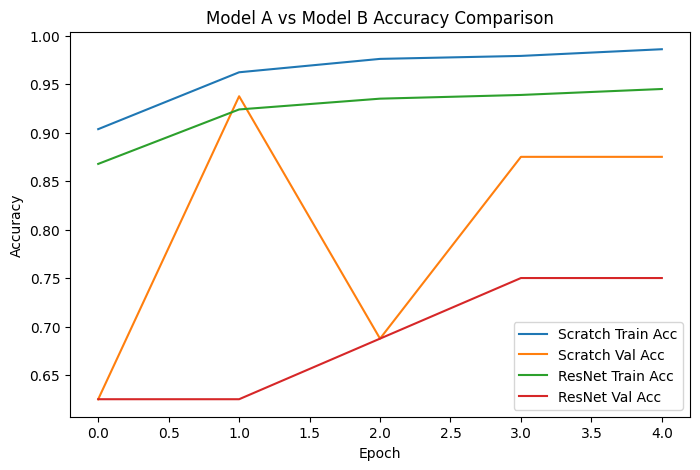

In [10]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Scratch Train Acc")
plt.plot(val_accs, label="Scratch Val Acc")

plt.plot(resnet_train_accs, label="ResNet Train Acc")
plt.plot(resnet_val_accs, label="ResNet Val Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model A vs Model B Accuracy Comparison")
plt.legend()
plt.show()


# **7) Test Data Comparison**

**Task: Compare the accuracies of both models on the test set**

In [11]:
loss_a, acc_a = evaluate(model_a, test_loader, criterion)
loss_b, acc_b = evaluate(model_b, test_loader, criterion)

print(f"Scratch CNN Test Accuracy: {acc_a:.4f}")
print(f"ResNet-18   Test Accuracy: {acc_b:.4f}")


Scratch CNN Test Accuracy: 0.7596
ResNet-18   Test Accuracy: 0.8077


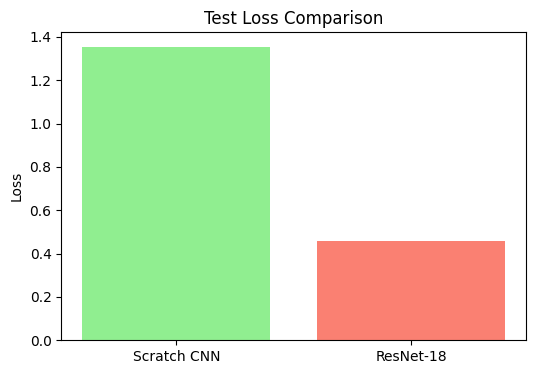

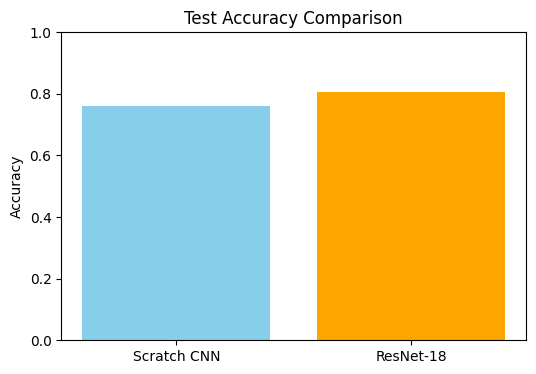

In [16]:
plt.figure(figsize=(6,4))
plt.bar(["Scratch CNN", "ResNet-18"], [loss_a, loss_b], color=["lightgreen", "salmon"])
plt.ylabel("Loss")
plt.title("Test Loss Comparison")
plt.show()
plt.figure(figsize=(6,4))
plt.bar(["Scratch CNN", "ResNet-18"], [acc_a, acc_b], color=["skyblue", "orange"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Test Accuracy Comparison")
plt.show()



## **8) Final Analysis & Conclusion**

**Task: Write your analysis here:**
- Why the pretrained model outperformed the scratch model
- Why transfer learning is essential for small datasets
- What features ImageNet CNNs learn that transfer to medical images
- Which model generalized better and why


**Answer:**
The pretrained model outperformed the scratch CNN because it started with useful features already learned from ImageNet, while the scratch model had to learn everything from zero.

Transfer learning is important for small datasets because the model doesn’t have enough images to discover strong features on its own. A pretrained model already knows basic visual patterns, so it learns faster and avoids overfitting.

ImageNet models learn general features like edges, textures, shapes, and contrast patterns. These also appear in medical images, so the same features transfer well to X-rays.

Overall, the pretrained ResNet generalized better because it had stronger starting knowledge and didn’t overfit, while the scratch CNN was more limited and less stable.